In [81]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from kneed import KneeLocator
from sklearn.metrics import confusion_matrix,adjusted_rand_score
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
pd.set_option('display.max_rows', 100)    
pd.set_option('display.max_columns', 50) 

In [3]:
data = pd.read_csv("./dataset/employee.csv")
df = data

In [4]:
data.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6


In [5]:
df.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6


### Data Cleaning

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               1470 non-null   object
 1   FirstName                1470 non-null   object
 2   LastName                 1470 non-null   object
 3   Gender                   1470 non-null   object
 4   Age                      1470 non-null   int64 
 5   BusinessTravel           1470 non-null   object
 6   Department               1470 non-null   object
 7   DistanceFromHome (KM)    1470 non-null   int64 
 8   State                    1470 non-null   object
 9   Ethnicity                1470 non-null   object
 10  Education                1470 non-null   int64 
 11  EducationField           1470 non-null   object
 12  JobRole                  1470 non-null   object
 13  MaritalStatus            1470 non-null   object
 14  Salary                   1470 non-null  

In [7]:
emp_id = LabelEncoder()
data["EmployeeID"] = emp_id.fit_transform(data["EmployeeID"])

In [8]:
data["EmployeeID"] = data["EmployeeID"].astype("int64")

In [9]:
gend = LabelEncoder()
data["Gender"] = gend.fit_transform(data["Gender"])

In [10]:
data["BusinessTravel"].unique()

array(['Some Travel', 'No Travel ', 'Frequent Traveller'], dtype=object)

In [11]:
b_trav = LabelEncoder()
data["BusinessTravel"] = b_trav.fit_transform(data["BusinessTravel"])

In [12]:
dep = LabelEncoder()
data["Department"] = dep.fit_transform(data["Department"])

In [13]:
stat = LabelEncoder()
data["State"] = stat.fit_transform(data["State"])

In [14]:
eth = LabelEncoder()
data["Ethnicity"] = eth.fit_transform(data["Ethnicity"])

In [15]:
field = LabelEncoder()
data["EducationField"] = field.fit_transform(data["EducationField"])

In [16]:
rol = LabelEncoder()
data["JobRole"] = rol.fit_transform(data["JobRole"])

In [17]:
mart = LabelEncoder()
data["MaritalStatus"] = stat.fit_transform(data["MaritalStatus"])

In [18]:
over = LabelEncoder()
data["OverTime"] = stat.fit_transform(data["OverTime"])

In [19]:
data["HireDate"] = data["HireDate"].astype("datetime64[ns]")

In [20]:
attr = LabelEncoder()
data["Attrition"] = attr.fit_transform(data["Attrition"])

In [21]:
data.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,275,Leonelle,Simco,0,30,2,1,27,1,6,...,0,102059,1,0,2012-01-03,0,10,4,9,7
1,1158,Leonerd,Aland,1,38,2,1,23,0,6,...,2,157718,0,1,2012-01-04,0,10,6,10,0
2,842,Ahmed,Sykes,1,43,2,0,29,0,1,...,1,309964,1,0,2012-01-04,0,10,6,10,8
3,402,Ermentrude,Berrie,2,39,2,2,12,1,6,...,1,293132,0,0,2012-01-05,0,10,10,10,0
4,369,Stace,Savege,0,29,2,0,29,0,6,...,2,49606,0,0,2012-01-05,1,6,1,1,6


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   EmployeeID               1470 non-null   int64         
 1   FirstName                1470 non-null   object        
 2   LastName                 1470 non-null   object        
 3   Gender                   1470 non-null   int64         
 4   Age                      1470 non-null   int64         
 5   BusinessTravel           1470 non-null   int64         
 6   Department               1470 non-null   int64         
 7   DistanceFromHome (KM)    1470 non-null   int64         
 8   State                    1470 non-null   int64         
 9   Ethnicity                1470 non-null   int64         
 10  Education                1470 non-null   int64         
 11  EducationField           1470 non-null   int64         
 12  JobRole                  1470 non-

In [30]:
x = data[["EmployeeID","Gender","Age","BusinessTravel","Department","DistanceFromHome (KM)","State","Ethnicity","Education","EducationField","JobRole","MaritalStatus","Salary","StockOptionLevel","OverTime","Attrition","YearsAtCompany","YearsInMostRecentRole","YearsSinceLastPromotion","YearsWithCurrManager"]]

In [29]:
x = data[["Education","JobRole","State","Gender","Age","EducationField"]]

In [57]:
y = data["Department"]

In [32]:
k_range = 

In [31]:
wcss = []
for k in range(1,20):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
print(wcss)

[15688821932596.031, 4099530706046.453, 2065925500033.3435, 1188710270444.2256, 750833929206.4777, 532623965617.0515, 389480168934.1934, 303280053789.9917, 238161673157.266, 202425463651.73233, 144580876808.07416, 124710670084.5967, 109058092508.19748, 99859927794.74792, 82442507806.00204, 71790525575.54976, 67169313159.9624, 63321717561.887955, 59386877787.99292]


<Axes: >

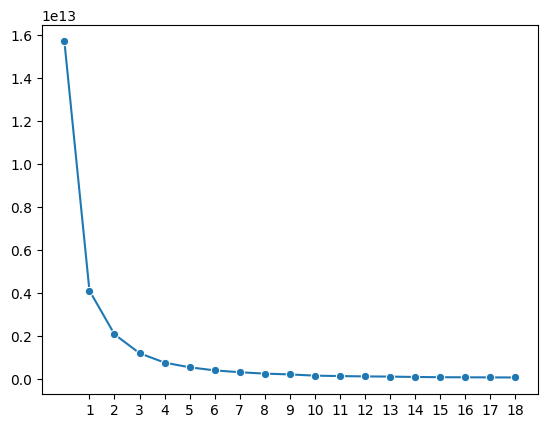

In [32]:
plt.xticks(range(1, len(wcss) + 1))
sns.lineplot(x=range(0,len(wcss)),y=wcss,marker = "o")

In [53]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(x)

KMeans(n_clusters=3, random_state=42)

In [55]:
y_pred = kmeans.labels_

In [59]:
rand_score = adjusted_rand_score(y, y_pred)
rand_score

0.03272759871278232

In [60]:
confusion_matrix(y,y_pred)

array([[ 26,  19,  18],
       [  0, 128, 318],
       [329, 239, 393]])

In [70]:
model = KMeans(n_clusters=2, init='k-means++', random_state=42)

In [71]:
model.fit(x)

KMeans(n_clusters=2, random_state=42)

In [72]:
labels = model.labels_

In [73]:
np.unique(labels)

array([0, 1], dtype=int32)

In [74]:
data["Cluster"] = labels

In [75]:
cluster_1 = data.loc[(data["Cluster"] == 0) ,:]

In [76]:
correlated_1 = cluster_1.corr(numeric_only = True)

<Axes: >

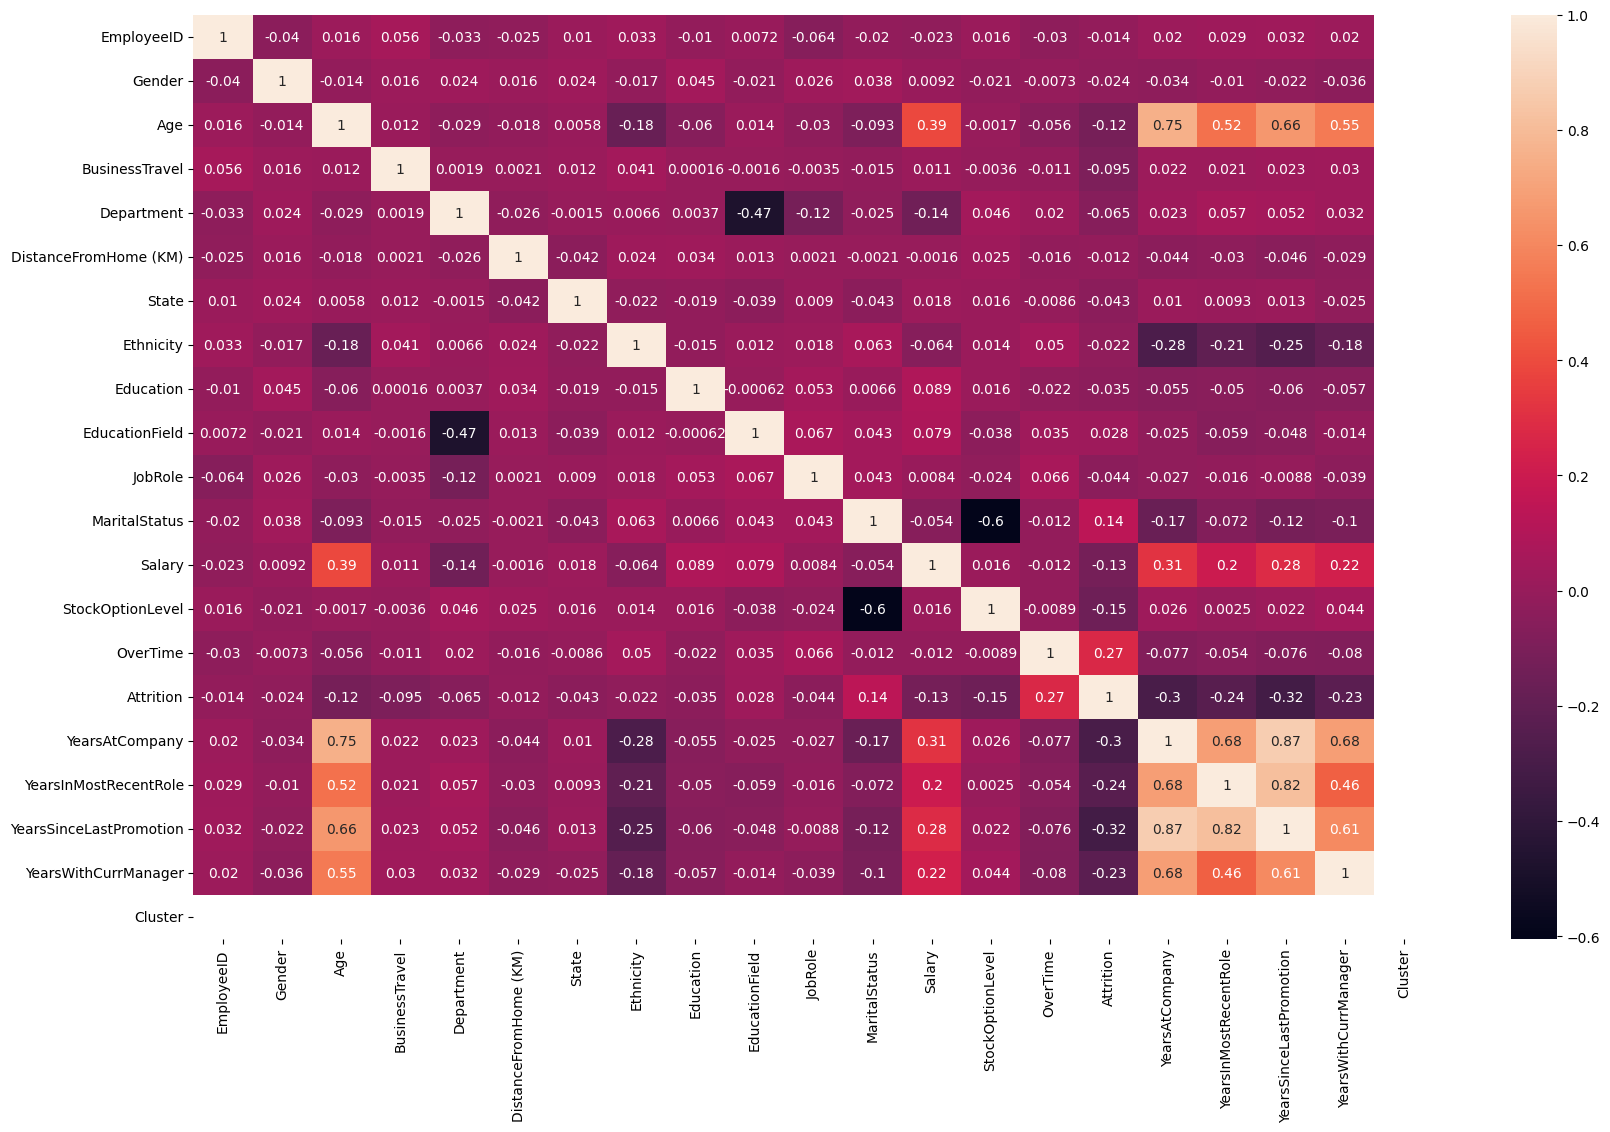

In [77]:
plt.figure(figsize=(20, 12))
sns.heatmap(data = correlated_1,annot=True)

In [78]:
cluster_2 = data.loc[(data["Cluster"] == 2) ,:]

In [79]:
correlated_2 = cluster_2.corr(numeric_only = True)

<Axes: >

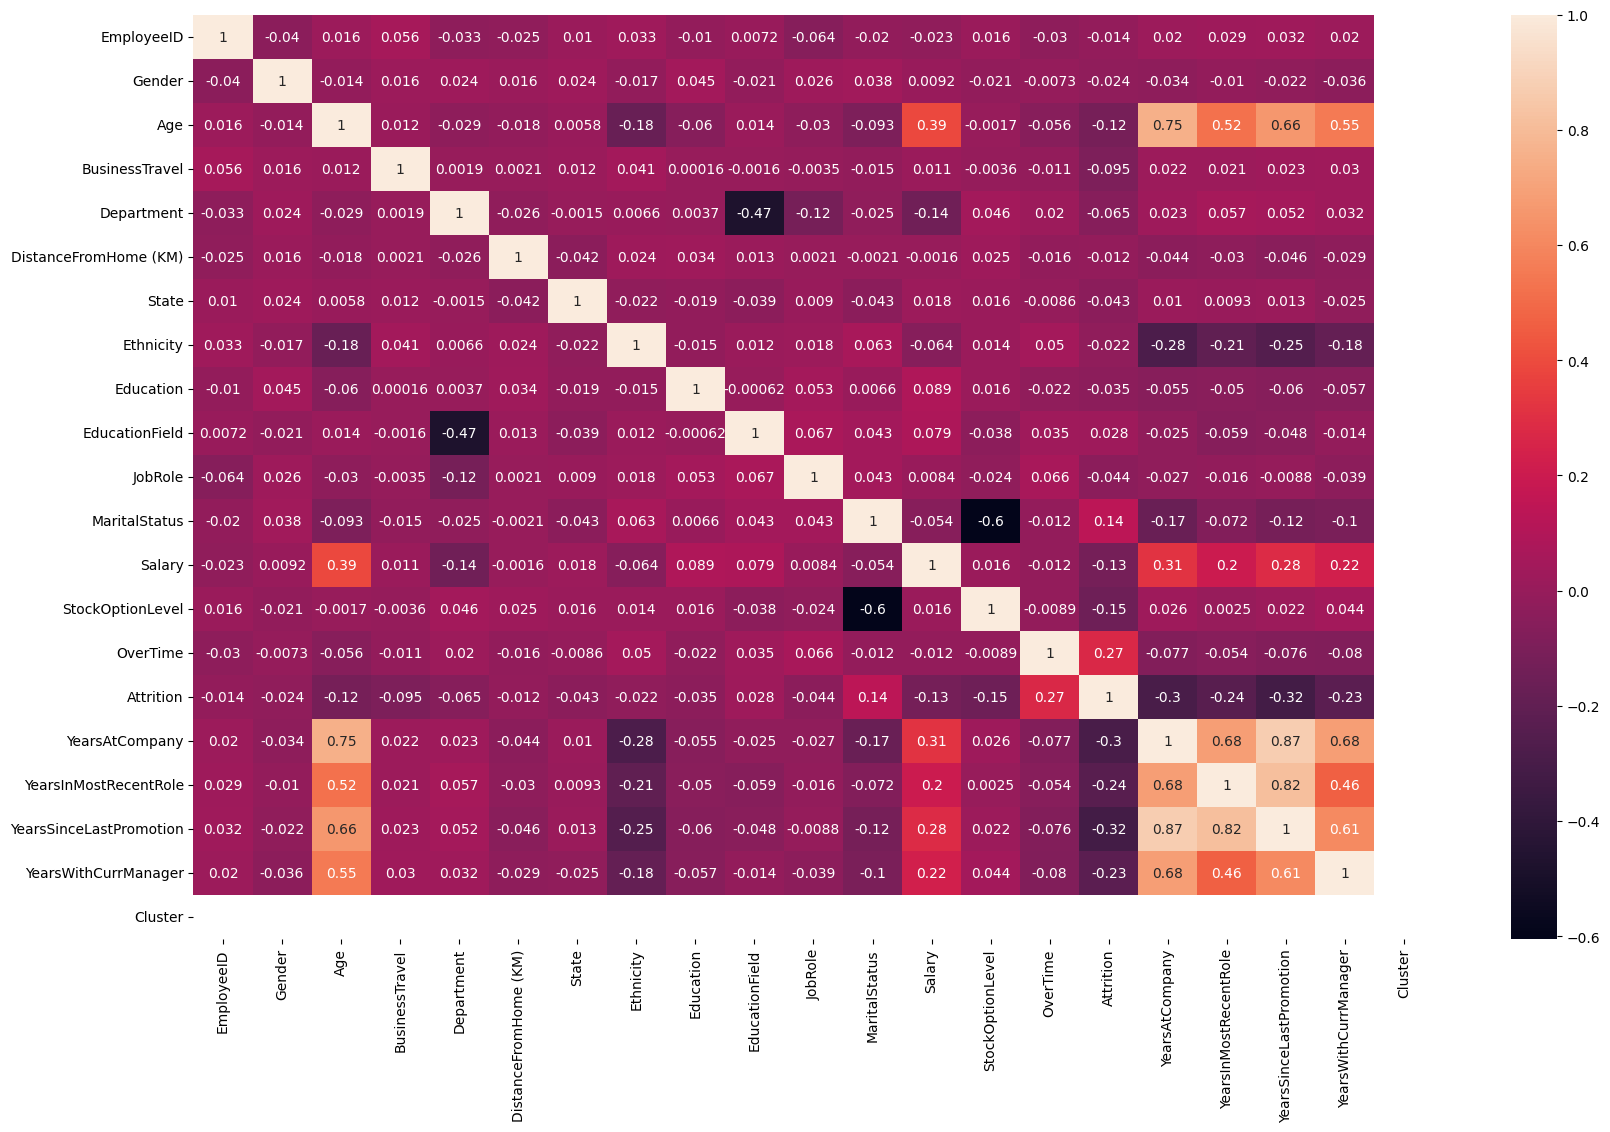

In [80]:
plt.figure(figsize=(20, 12))
sns.heatmap(data = correlated_1,annot=True)

## Silhouette Evaluvation 

In [84]:
best_k = 0
best_score = -1
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    
    score = silhouette_score(x, labels)
    scores.append((k, score))

    print(f"k = {k}, Silhouette Score = {score:.4f}")
    
    if score > best_score:
        best_k = k
        best_score = score

print(f"\n✅ Best number of clusters: k = {best_k} with Silhouette Score = {best_score:.4f}")

k = 2, Silhouette Score = 0.7370
k = 3, Silhouette Score = 0.6718
k = 4, Silhouette Score = 0.6167
k = 5, Silhouette Score = 0.6120
k = 6, Silhouette Score = 0.5857
k = 7, Silhouette Score = 0.5619
k = 8, Silhouette Score = 0.5591
k = 9, Silhouette Score = 0.5598
k = 10, Silhouette Score = 0.5452

✅ Best number of clusters: k = 2 with Silhouette Score = 0.7370


using sillouhete the best clisters is 2